In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('Short_order_dataset_final.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2245 entries, 0 to 2244
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       2245 non-null   int64  
 1   CustomerID    2245 non-null   int64  
 2   UnitsOrdered  2245 non-null   int64  
 3   Discount      2245 non-null   float64
 4   Description   2245 non-null   object 
 5   Gender        2245 non-null   object 
 6   UnitPrice     2245 non-null   int64  
 7   Name          2245 non-null   object 
 8   City          2245 non-null   object 
 9   State         2245 non-null   object 
 10  full_date     2245 non-null   object 
 11  year          2245 non-null   int64  
 12  month         2245 non-null   int64  
 13  day           2245 non-null   int64  
 14  Revenue       2245 non-null   float64
dtypes: float64(2), int64(7), object(6)
memory usage: 263.2+ KB


<Axes: >

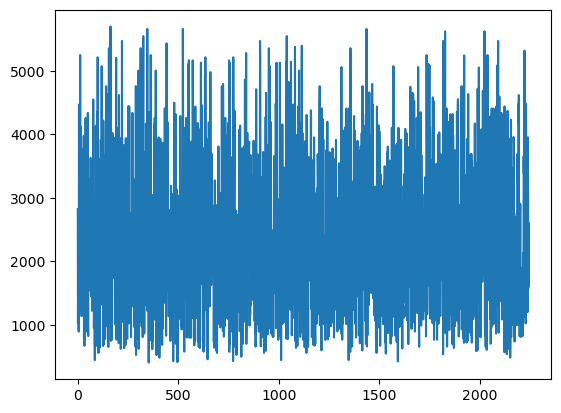

In [11]:
df.Revenue.plot()

In [6]:
df['full_date'] = pd.to_datetime(df['full_date'])
df_daily = df.groupby(df['full_date'].dt.date).agg({'Revenue': 'sum'}).reset_index()
df_daily['full_date'] = pd.to_datetime(df_daily['full_date'])
df_daily.set_index('full_date', inplace=True)
df_daily

,Revenue
full_date,
2012-01-02,5801.0
2012-01-03,3668.0
2012-01-05,7940.0
2012-01-07,2385.0
2012-01-08,2275.0
...,...
2016-12-19,2212.0
2016-12-20,7886.0
2016-12-24,3321.0


In [9]:
df_daily = df_daily.asfreq('D')
df_daily.isna().sum()

Revenue    553
dtype: int64

In [11]:
df_daily.fillna(0, inplace=True)
df_daily.isna().sum()

Revenue    0
dtype: int64

In [13]:
size = int(len(df_daily)*0.8)
size

1458

In [15]:
df_train = df_daily.iloc[:size]
df_train

,Revenue
full_date,
2012-01-02,5801.0
2012-01-03,3668.0
2012-01-04,0.0
2012-01-05,7940.0
2012-01-06,0.0
...,...
2015-12-25,0.0
2015-12-26,4788.0
2015-12-27,0.0


In [17]:
df_test = df_daily.iloc[size:]
df_test

,Revenue
full_date,
2015-12-30,0.0
2015-12-31,0.0
2016-01-01,3125.0
2016-01-02,0.0
2016-01-03,5661.0
...,...
2016-12-24,3321.0
2016-12-25,0.0
2016-12-26,1577.0


<font size="5">
Checking if data is stationary using Dickey-Fuller (ADF) test

In [20]:
import statsmodels.tsa.stattools as sts
sts.adfuller(df_daily.Revenue)

(-42.56003043464878,
 0.0,
 0,
 1822,
 {'1%': -3.4339441475744668,
  '5%': -2.8631276157416945,
  '10%': -2.5676151930364455},
 33805.99615638008)

<font size="5">
Conducting Auto-correlation function (ACF)

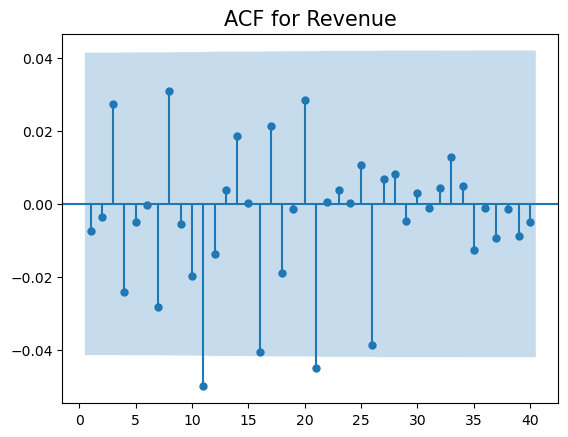

In [22]:
import statsmodels.graphics.tsaplots as sgt
sgt.plot_acf(df.Revenue, lags = 40, zero = False)
plt.title("ACF for Revenue", size = 15)
plt.autoscale()
plt.show()

<font size="5">
ARIMA model training iterations

In [24]:
from statsmodels.tsa.arima.model import ARIMA

In [26]:
model_ar_1_i_1_ma_1 = ARIMA(df_train.Revenue, order = (1,1,1))
results_ar_1_i_1_ma_1 = model_ar_1_i_1_ma_1.fit()
results_ar_1_i_1_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                 1458
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13722.290
Date:                Fri, 11 Oct 2024   AIC                          27450.579
Time:                        16:16:16   BIC                          27466.432
Sample:                    01-02-2012   HQIC                         27456.493
                         - 12-29-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0044      0.021      0.208      0.835      -0.037       0.045
ma.L1         -1.0000      0.025    -39.669      0.000      -1.049      -0.951
sigma2      8.833e+06   2.84e-09   3.11e+15      0.000    8.83e+06    8.83e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               793.00
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                             1.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.17e+29. Standard errors may be unstable.
"""

In [27]:
model_ar_3_i_3_ma_2 = ARIMA(df_daily.Revenue, order = (3,3,2))
results_ar_3_i_3_ma_2 = model_ar_3_i_3_ma_2.fit()
results_ar_3_i_3_ma_2.summary()

D:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                 1823
Model:                 ARIMA(3, 3, 2)   Log Likelihood              -17561.431
Date:                Fri, 11 Oct 2024   AIC                          35134.863
Time:                        16:16:18   BIC                          35167.902
Sample:                    01-02-2012   HQIC                         35147.052
                         - 12-28-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7520      0.045    -16.603      0.000      -0.841      -0.663
ar.L2         -0.5235      0.048    -10.999      0.000      -0.617      -0.430
ar.L3         -0.2799      0.046     -6.149      0.000      -0.369      -0.191
ma.L1         -1.9974      0.040    -50.241      0.000      -2.075      -1.919
ma.L2          0.9978      0.040     25.089      0.000       0.920       1.076
sigma2      2.386e+07   1.27e-09   1.88e+16      0.000    2.39e+07    2.39e+07
===================================================================================
Ljung-Box (L1) (Q):                   5.46   Jarque-Bera (JB):               284.43
Prob(Q):                              0.02   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                             0.74
Prob(H) (two-sided):                  0.43   Kurtosis:                         4.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.34e+31. Standard errors may be unstable.
"""

In [29]:
model_ar_2_i_2_ma_1 = ARIMA(df_daily.Revenue, order = (2,2,1))
results_ar_2_i_2_ma_1 = model_ar_2_i_2_ma_1.fit()
results_ar_2_i_2_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                 1823
Model:                 ARIMA(2, 2, 1)   Log Likelihood              -17426.371
Date:                Fri, 11 Oct 2024   AIC                          34860.742
Time:                        16:16:19   BIC                          34882.771
Sample:                    01-02-2012   HQIC                         34868.869
                         - 12-28-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6571      0.019    -34.487      0.000      -0.694      -0.620
ar.L2         -0.3408      0.019    -18.233      0.000      -0.377      -0.304
ma.L1         -1.0000      0.027    -37.696      0.000      -1.052      -0.948
sigma2      1.197e+07   2.22e-09    5.4e+15      0.000     1.2e+07     1.2e+07
===================================================================================
Ljung-Box (L1) (Q):                  16.94   Jarque-Bera (JB):               237.65
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.64
Prob(H) (two-sided):                  0.87   Kurtosis:                         4.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.23e+29. Standard errors may be unstable.
"""

<font size="5">
Conducting log-likelyhood test

In [33]:
from scipy.stats.distributions import chi2
def LLR_test(mod_1,mod_2,DF=1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR,DF).round(3)
    return print("p value is:",p)

In [34]:
LLR_test(model_ar_3_i_3_ma_2, model_ar_2_i_2_ma_1, DF = 2)

D:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


p value is: 0.0


<font size="5">
Forecasting

In [39]:
df_train.tail()

,Revenue
full_date,
2015-12-25,0.0
2015-12-26,4788.0
2015-12-27,0.0
2015-12-28,1715.0
2015-12-29,0.0


In [40]:
start_index = "2015-12-30"
end_index = "2016-2-28"

In [41]:
df_pred = results_ar_3_i_3_ma_2.predict(start = start_index, end = end_index)
df_pred

full_date
2015-12-30    1720.260079
2015-12-31     399.610396
2016-01-01     458.726231
2016-01-02     758.851065
2016-01-03     694.370659
                 ...     
2016-02-24    2365.730556
2016-02-25    2555.254724
2016-02-26    2586.683730
2016-02-27     278.560134
2016-02-28     293.728908
Freq: D, Name: predicted_mean, Length: 61, dtype: float64

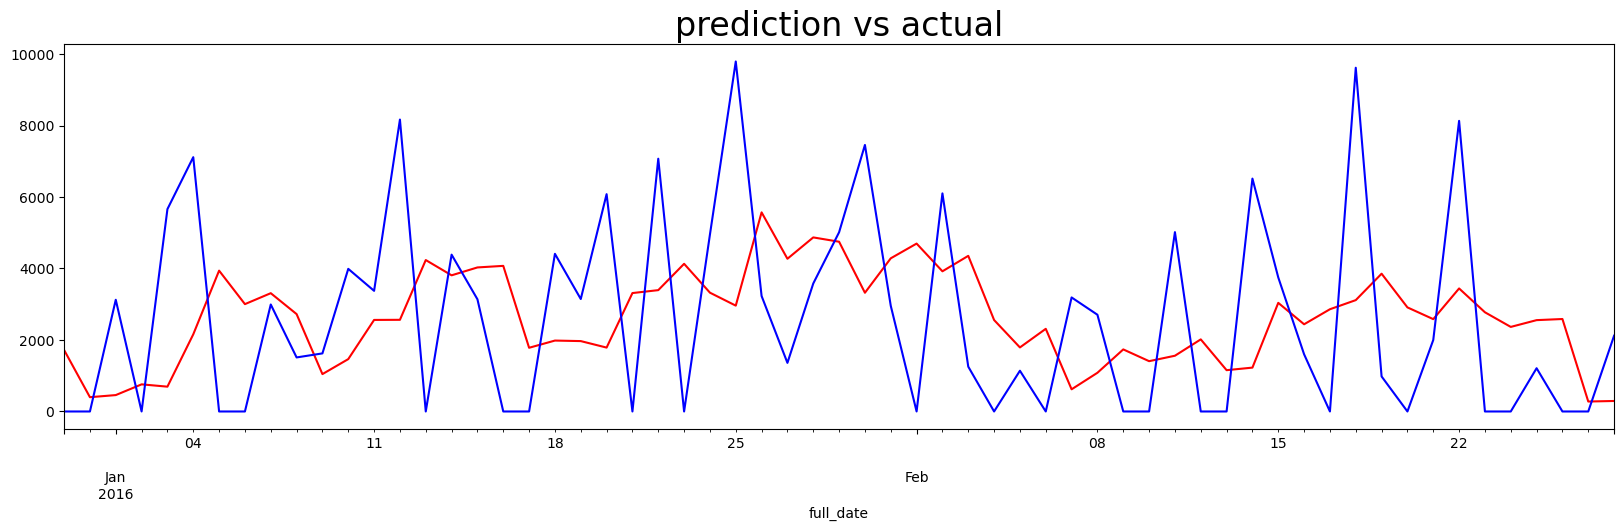

In [46]:
df_pred[start_index:end_index].plot(figsize = (20,5), color = "red")
df_test.Revenue[start_index:end_index].plot(color = "blue")
plt.title("prediction vs actual", size = 24)
plt.show()

<font size="5">
Trying Auto-ARIMA

In [49]:
from pmdarima.arima import auto_arima

In [51]:
model_auto = auto_arima(df_train.Revenue)
model_auto

ARIMA(order=(0, 0, 0), scoring_args={}, suppress_warnings=True)

In [53]:
model_auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1458
Model:                        SARIMAX   Log Likelihood              -13728.360
Date:                Fri, 11 Oct 2024   AIC                          27460.719
Time:                        16:16:26   BIC                          27471.289
Sample:                    01-02-2012   HQIC                         27464.663
                         - 12-29-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2938.5185     98.727     29.764      0.000    2745.017    3132.020
sigma2      8.832e+06   2.72e+05     32.413      0.000     8.3e+06    9.37e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               849.30
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               0.76   Skew:                             1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [55]:
df_pred_auto = model_auto.predict(start = start_index, end = end_index)
df_pred_auto

2015-12-30    2938.518519
2015-12-31    2938.518519
2016-01-01    2938.518519
2016-01-02    2938.518519
2016-01-03    2938.518519
2016-01-04    2938.518519
2016-01-05    2938.518519
2016-01-06    2938.518519
2016-01-07    2938.518519
2016-01-08    2938.518519
Freq: D, dtype: float64

2015-12-30    2938.518519
2015-12-31    2938.518519
2016-01-01    2938.518519
2016-01-02    2938.518519
2016-01-03    2938.518519
2016-01-04    2938.518519
2016-01-05    2938.518519
2016-01-06    2938.518519
2016-01-07    2938.518519
2016-01-08    2938.518519
Freq: D, dtype: float64


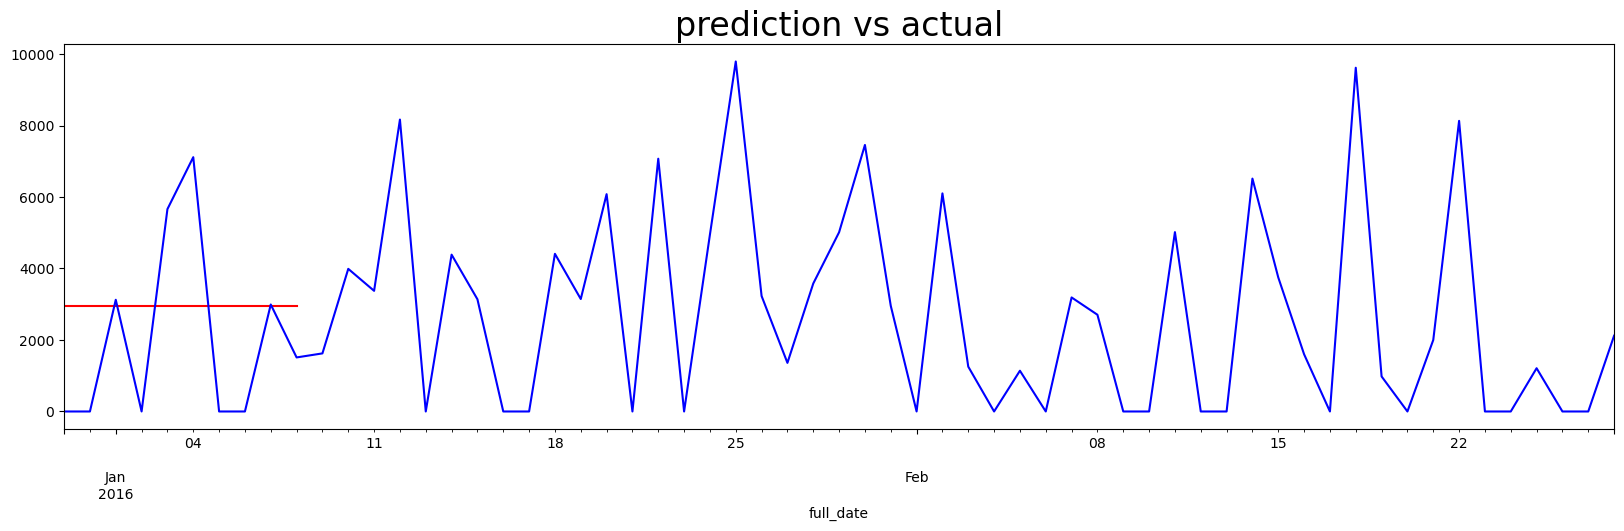

In [57]:
df_pred_auto[start_index:end_index].plot(figsize = (20,5), color = "red")
df_test.Revenue[start_index:end_index].plot(color = "blue")
plt.title("prediction vs actual", size = 24)
plt.show()

In [59]:
df_train.mean()

Revenue    2938.518519
dtype: float64

<font size="8">
Performance metrics

<font size="5">
Mean absolute error

In [63]:
from sklearn.metrics import mean_absolute_error

# Actual and predicted values
y_true = df_test.Revenue[start_index:end_index]
y_pred = df_pred[start_index:end_index]

# Calculate MAE
mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae}")

MAE: 2502.6340699910684


<font size="5">
Mean squared error

In [66]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse}")

MSE: 8836807.42915931


<font size="5">
Root mean squared error

In [69]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse}")

RMSE: 2972.676812093657


<font size="5">
R-squared

In [72]:
from sklearn.metrics import r2_score

# Calculate R-squared
r2 = -r2_score(y_true, y_pred)
print(f"R-squared: {r2}")

R-squared: 0.13457797666927673


<font size="5">
Logging model with its parameters and metrics to MLFLOW

In [83]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000/") 

# Start a new MLflow run
with mlflow.start_run():
    mlflow.log_param("model_type", "ARIMA")
    # Log metrics
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r-squared", r2)
    #Log parameters
    mlflow.log_param("p", 3)
    mlflow.log_param("d", 3)
    mlflow.log_param("q", 2)
    
    # Log the model itself
    mlflow.sklearn.log_model(model_ar_3_i_3_ma_2, "model")

2024/10/11 16:24:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2024/10/11 16:24:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run skittish-grouse-310 at: http://127.0.0.1:5000/#/experiments/0/runs/702aa0a3b5524632a236d321233cba71.
2024/10/11 16:24:11 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0.


In [ ]:
# task of week 4

In [ ]:
# Install MLflow if not already installed  !pip install mlflow


import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Sample data (Replace with your dataset)
data = pd.read_csv("your_dataset.csv")  # Load your data here
X = data.drop('target_column', axis=1)
y = data['target_column']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define your model (Replace with your model)
model = LinearRegression()

# Start the MLflow run
with mlflow.start_run():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Log parameters
    mlflow.log_param("model_type", "Linear Regression")
    
    # Log metrics
    mse = mean_squared_error(y_test, predictions)
    mlflow.log_metric("mean_squared_error", mse)
    
    # Log the model
    mlflow.sklearn.log_model(model, "model")
    
    print(f"Logged MSE: {mse}")
    print("Model and metrics logged in MLflow")

# You can view the MLflow logs by running `mlflow ui` in your terminal


In [ ]:
# !pip install streamlit
# Save this as app.py
import streamlit as st
import pickle  # To load the saved model
import numpy as np

# Load the saved model (replace 'model.pkl' with your saved model path)
model = pickle.load(open('model.pkl', 'rb'))

st.title("Shirt Order Forecasting")

# Create input fields for user data
input_data = []
num_features = 3  # Adjust based on your model's features
for i in range(num_features):
    input_val = st.number_input(f"Input feature {i+1}", 0.0, 100.0)
    input_data.append(input_val)

# Convert to NumPy array
input_array = np.array(input_data).reshape(1, -1)

# Make prediction
if st.button("Predict"):
    prediction = model.predict(input_array)
    st.write(f"Predicted value: {prediction[0]}")



In [ ]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)
